In [1]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
!pip install shapely
from shapely.geometry import Point
from shapely import plotting

# Zugriff auf Vorlesungsordner
sys.path.append("./Lectures")

# Eigene Benchmarks importieren
from myBenchmarks import getAllBenchmarks
from IPPlanarManipulator import PlanarRobot
from IPEnvironmentKin import KinChainCollisionChecker, planarRobotVisualize, animateSolution
from IPPerfMonitor import IPPerfMonitor
# Planner & Visuals
from IPBasicPRM import BasicPRM
from IPVisibilityPRM import VisPRM
from IPLazyPRM import LazyPRM
from IPHierarchicalPRM import HierarchicalPRM

from IPVISBasicPRM import basicPRMVisualize
from IPVISVisibilityPRM import visibilityPRMVisualize
from IPVISLazyPRM import lazyPRMVisualize
from IPVISHierarchicalPRM import hierarchicalPRMVisualizeSteps
from IPVISHierarchicalPRM import hierarchicalPRMVisualizeLazySteps

In [2]:
# 🔧 Planner Setup (KIT Style)
plannerFactory = dict()

basicConfig = dict()
basicConfig["radius"] = 4
basicConfig["numNodes"] = 50
#plannerFactory["BasicPRM"] = [BasicPRM, basicConfig, basicPRMVisualize]

visConfig = dict()
visConfig["ntry"] = 1000
plannerFactory["VisPRM"] = [VisPRM, visConfig, visibilityPRMVisualize]

lazyConfig = dict()
lazyConfig["initialRoadmapSize"] = 20
lazyConfig["updateRoadmapSize"] = 5
lazyConfig["kNearest"] = 10
lazyConfig["maxIterations"] = 5
plannerFactory["LazyPRM"] = [LazyPRM, lazyConfig, lazyPRMVisualize]

hierarchicalConfig = dict()
hierarchicalConfig["mainPlanner"] = VisPRM
hierarchicalConfig["mainConfig"] = visConfig
hierarchicalConfig["subPlanner"] = BasicPRM
hierarchicalConfig["subConfig"] = basicConfig
plannerFactory["HierarchicalPRM"] = [HierarchicalPRM, hierarchicalConfig, hierarchicalPRMVisualizeSteps]

In [3]:
# 🧪 Test Benchmarks laden
benchmarks = getAllBenchmarks()



🔍 HierarchicalPRM → Trap

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 9 nodes, 8 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 9 nodes, 8 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 11 nodes, 10 edges
✅ Pfad gefunden!


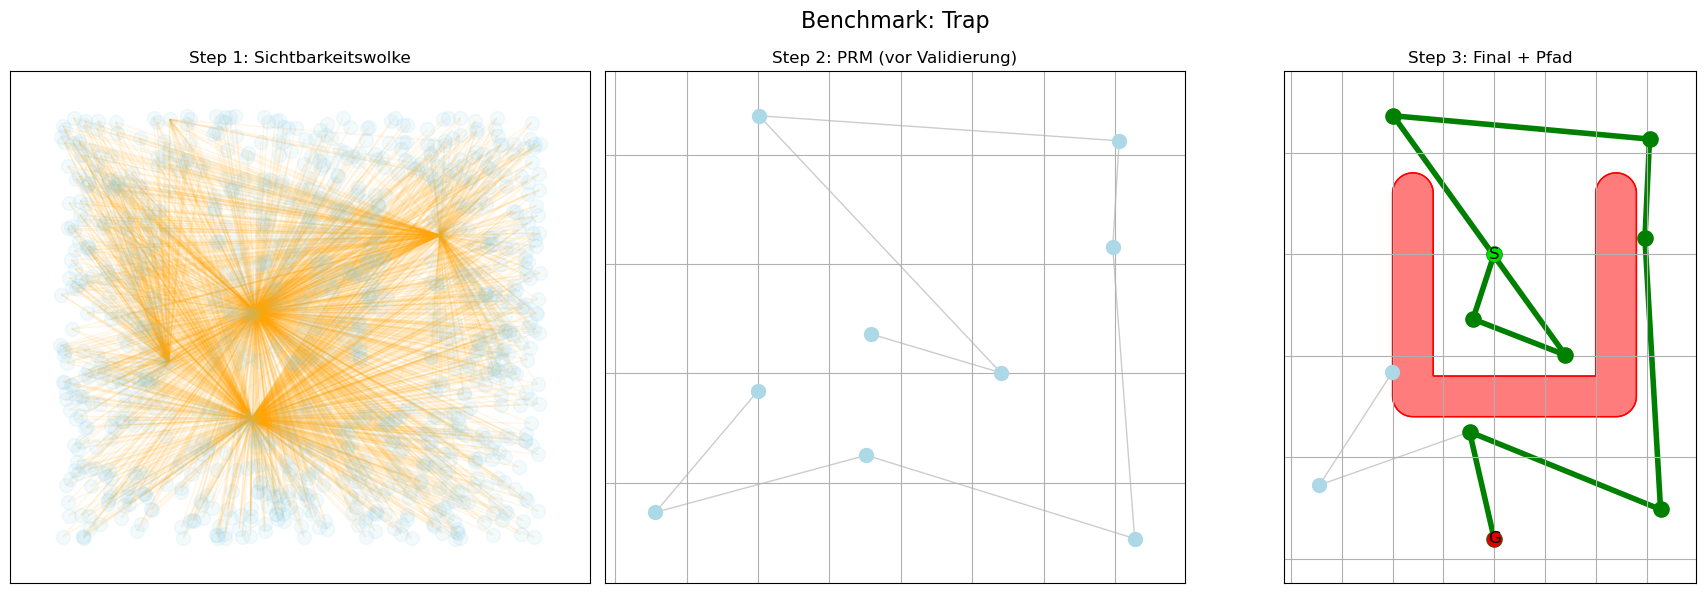


🔍 HierarchicalPRM → Bottleneck

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 3 nodes, 2 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 3 nodes, 2 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 5 nodes, 4 edges
✅ Pfad gefunden!


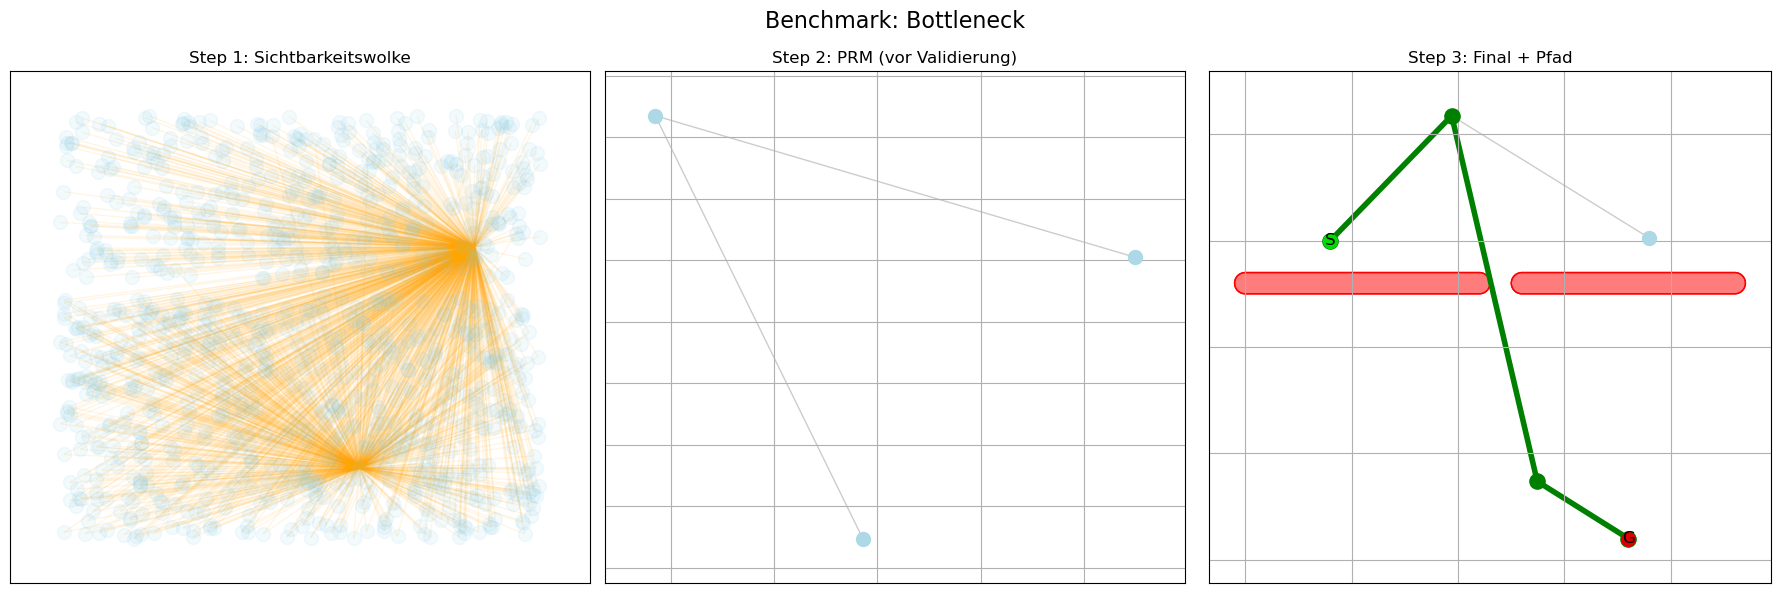


🔍 HierarchicalPRM → Fat Bottleneck

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 3 nodes, 2 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 3 nodes, 2 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 5 nodes, 4 edges
✅ Pfad gefunden!


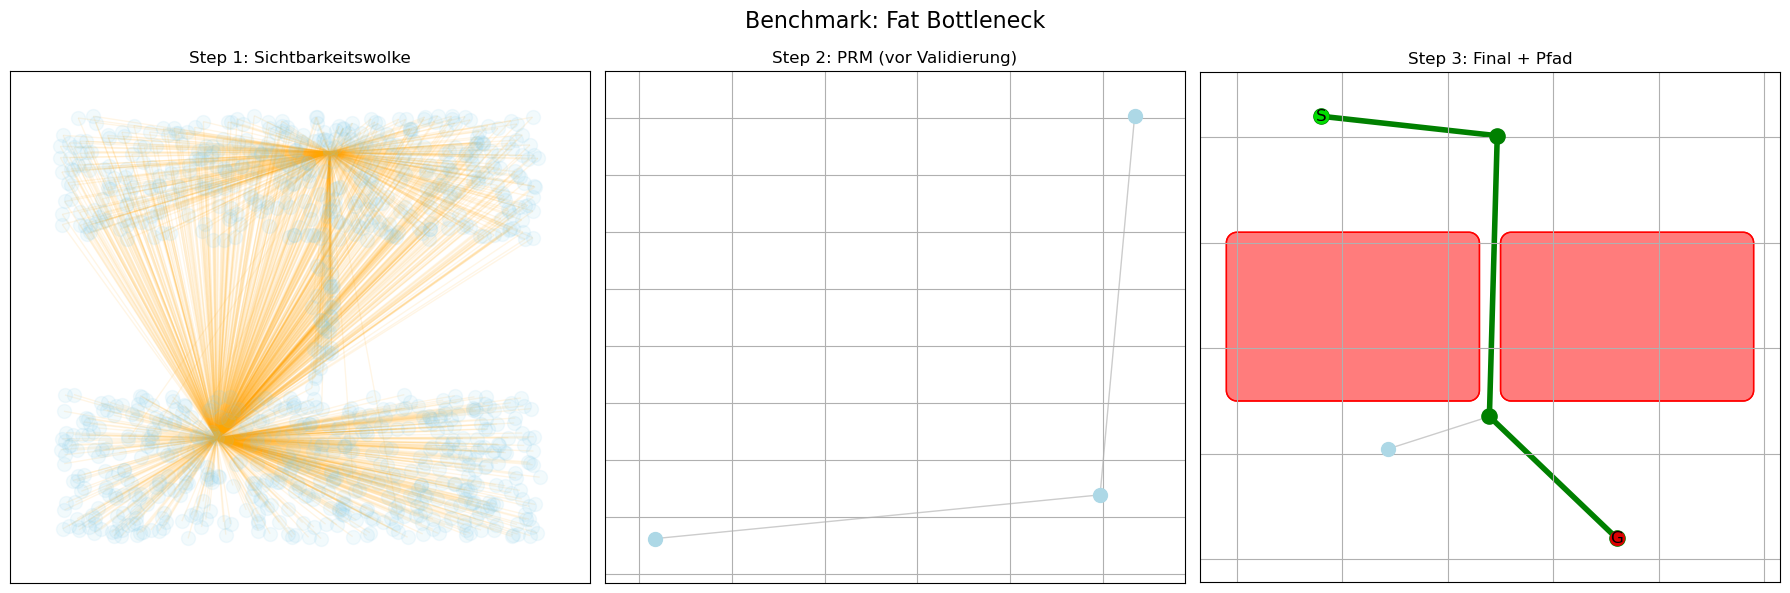


🔍 HierarchicalPRM → LTC Maze

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 12 nodes, 10 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 12 nodes, 10 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 14 nodes, 12 edges
✅ Pfad gefunden!


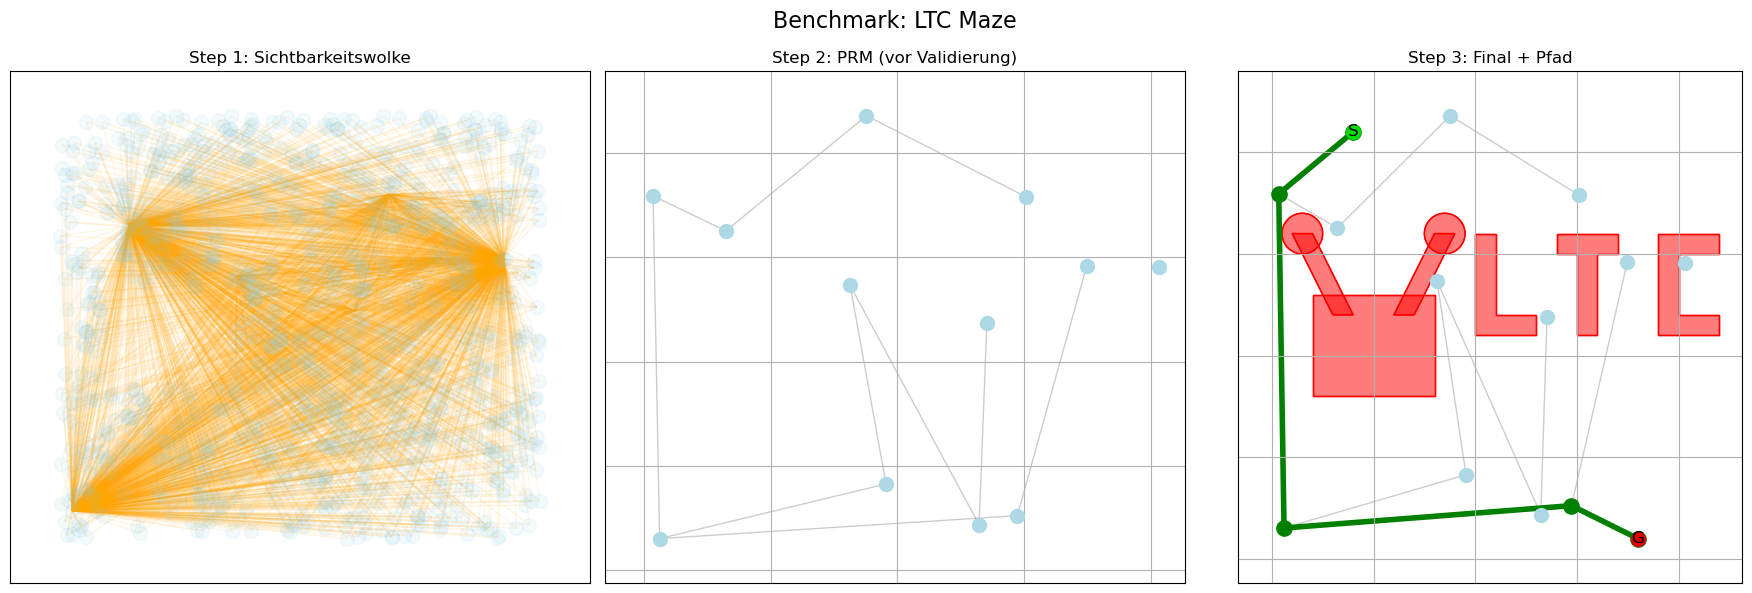


🔍 HierarchicalPRM → Maze Corridor

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 13 nodes, 12 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 13 nodes, 12 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 15 nodes, 14 edges
✅ Pfad gefunden!


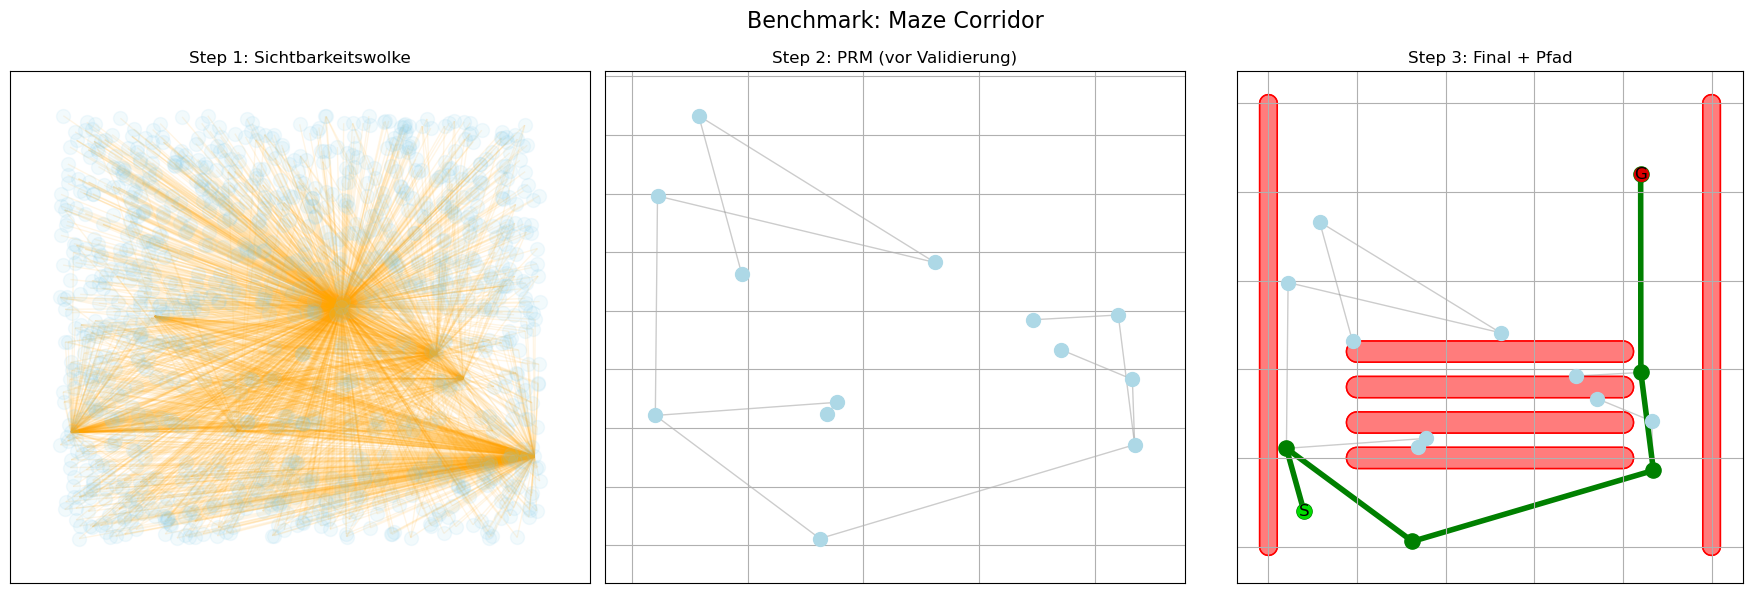


🔍 HierarchicalPRM → Diagonal Wall

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 5 nodes, 4 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 5 nodes, 4 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 7 nodes, 6 edges
✅ Pfad gefunden!


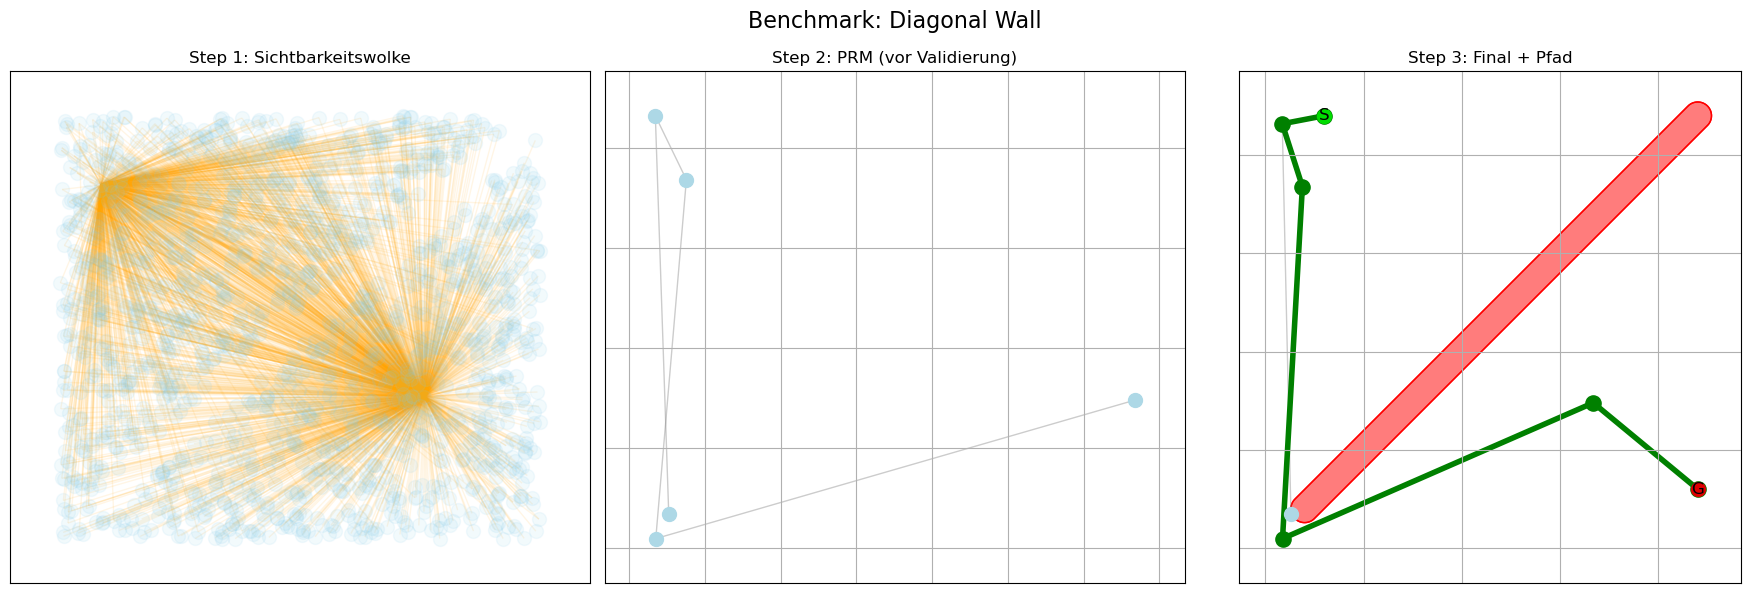


🔍 HierarchicalPRM → Corridor Split

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 2 nodes, 0 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 2 nodes, 0 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 2 nodes, 0 edges
❌ Kein Pfad gefunden.


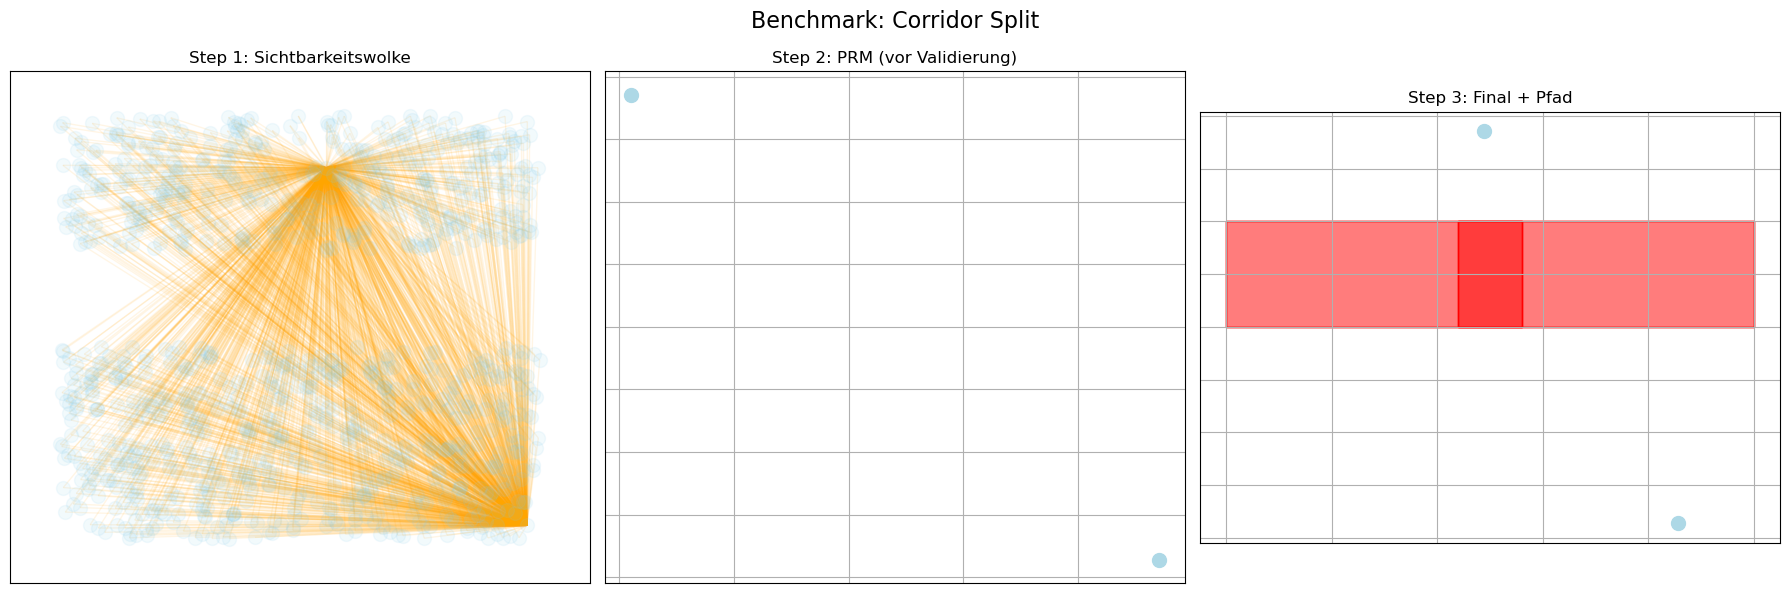

In [4]:
# 🔁 Für alle Benchmarks: HierarchicalPRM ausführen und visualisieren (3-Stufen-Darstellung)

# Setup der Planner-Factories
mainPlannerFactory = lambda cc: VisPRM(cc)
subPlannerFactory = lambda cc: BasicPRM(cc)

# Konfiguration (z. B. für VisPRM)
visConfig = dict()
visConfig["ntry"] = 1000

# Benchmark-Schleife
for benchmark in benchmarks:
    print(f"\n🔍 HierarchicalPRM → {benchmark.name}")
    
    # 1. Planer instanziieren
    planner = HierarchicalPRM(benchmark.collisionChecker, mainPlannerFactory, subPlannerFactory)

    # 2. Pfad berechnen
    path = planner.planPath(benchmark.startList, benchmark.goalList, visConfig)

    # 3. Visualisierung (3 Schritte)
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    hierarchicalPRMVisualizeSteps(planner, axs)
    fig.suptitle(f"Benchmark: {benchmark.name}", fontsize=16)
    plt.tight_layout()
    plt.show()



🔍 HierarchicalPRM → Trap

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 7 nodes, 6 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 7 nodes, 6 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 9 nodes, 8 edges
✅ Pfad gefunden!


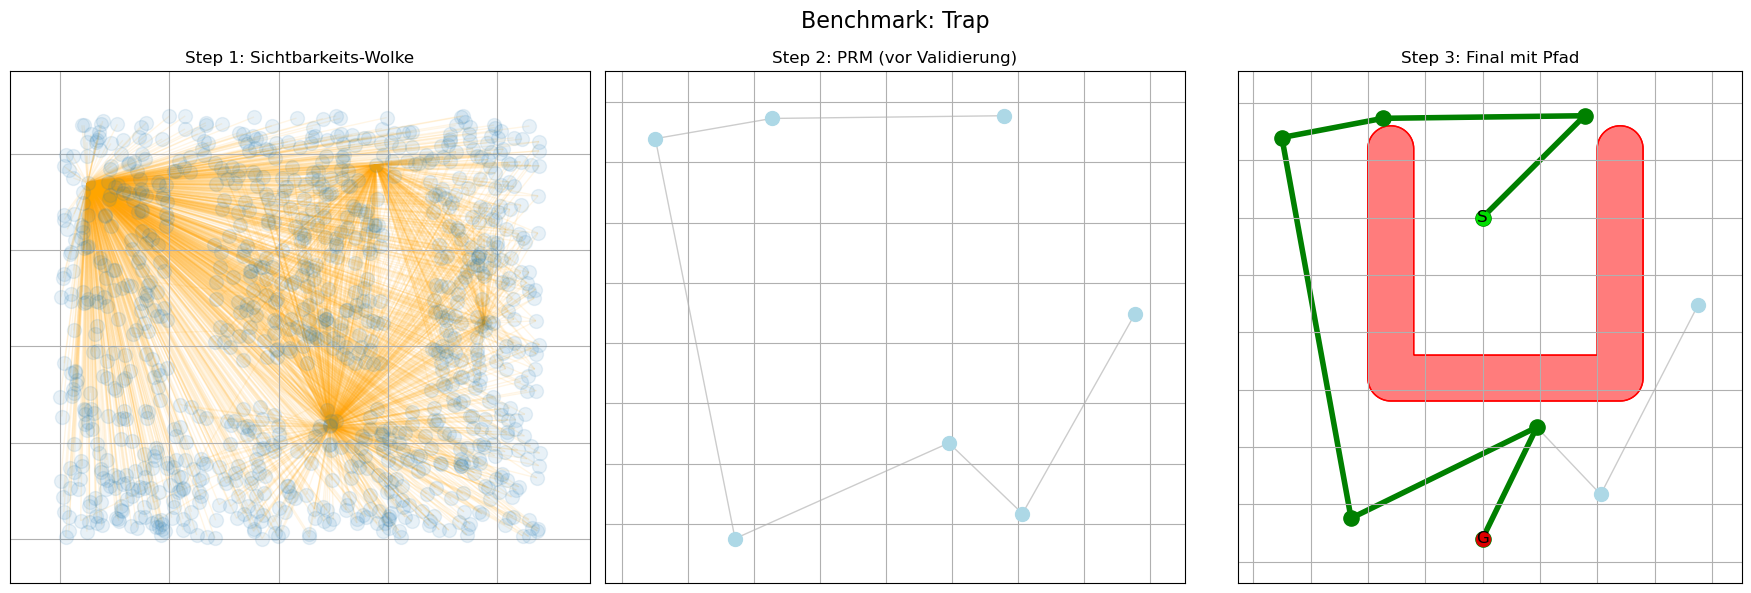


🔍 HierarchicalPRM → Bottleneck

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 3 nodes, 2 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 3 nodes, 2 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 5 nodes, 4 edges
✅ Pfad gefunden!


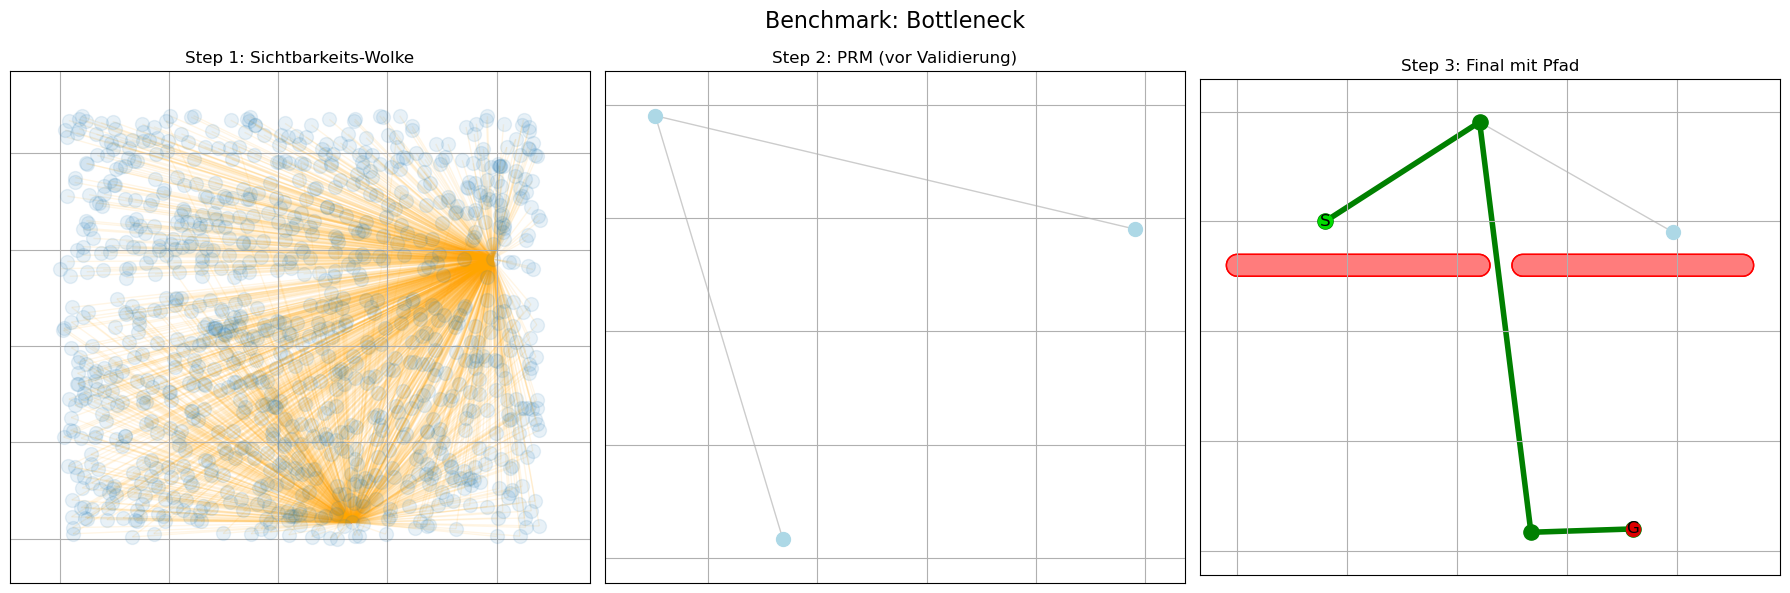


🔍 HierarchicalPRM → Fat Bottleneck

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 3 nodes, 2 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 3 nodes, 2 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 5 nodes, 4 edges
✅ Pfad gefunden!


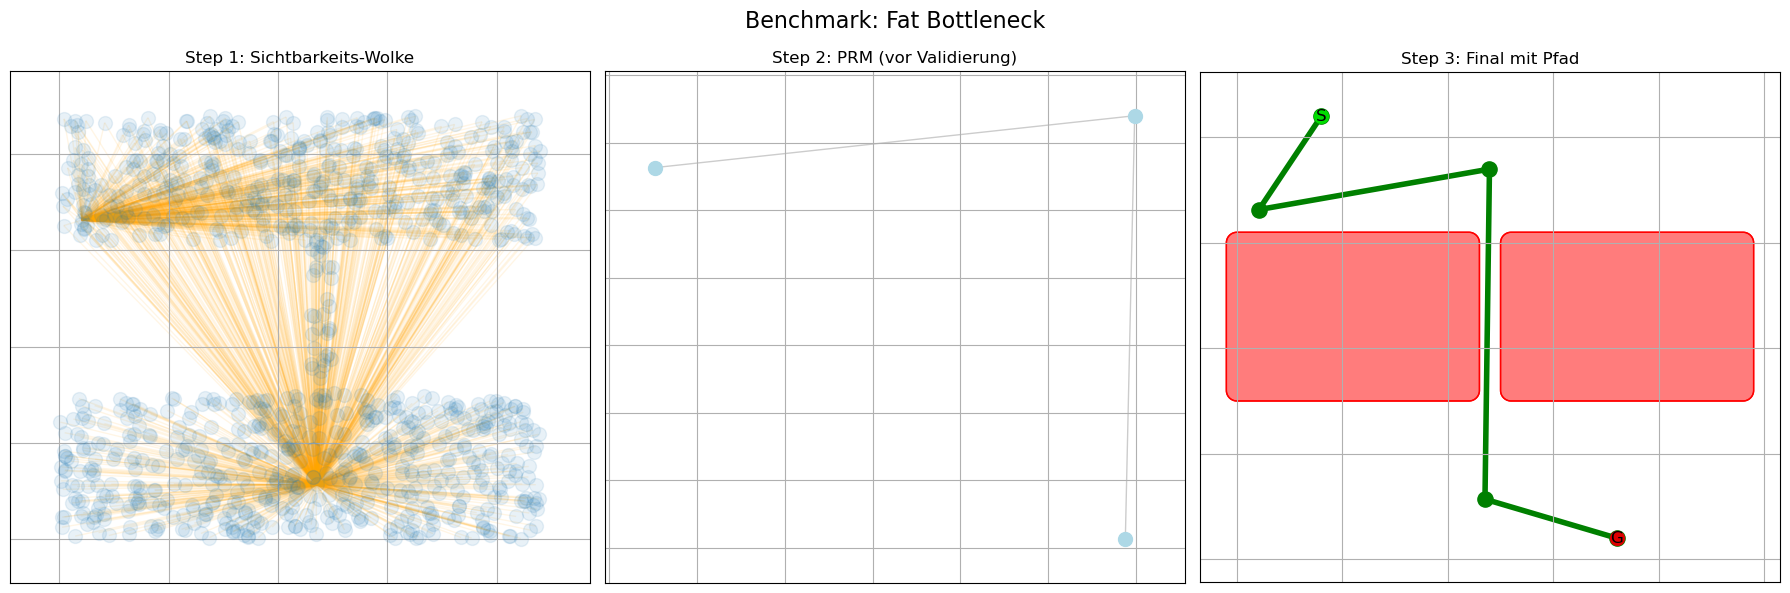


🔍 HierarchicalPRM → LTC Maze

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 20 nodes, 18 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 20 nodes, 18 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 22 nodes, 20 edges
✅ Pfad gefunden!


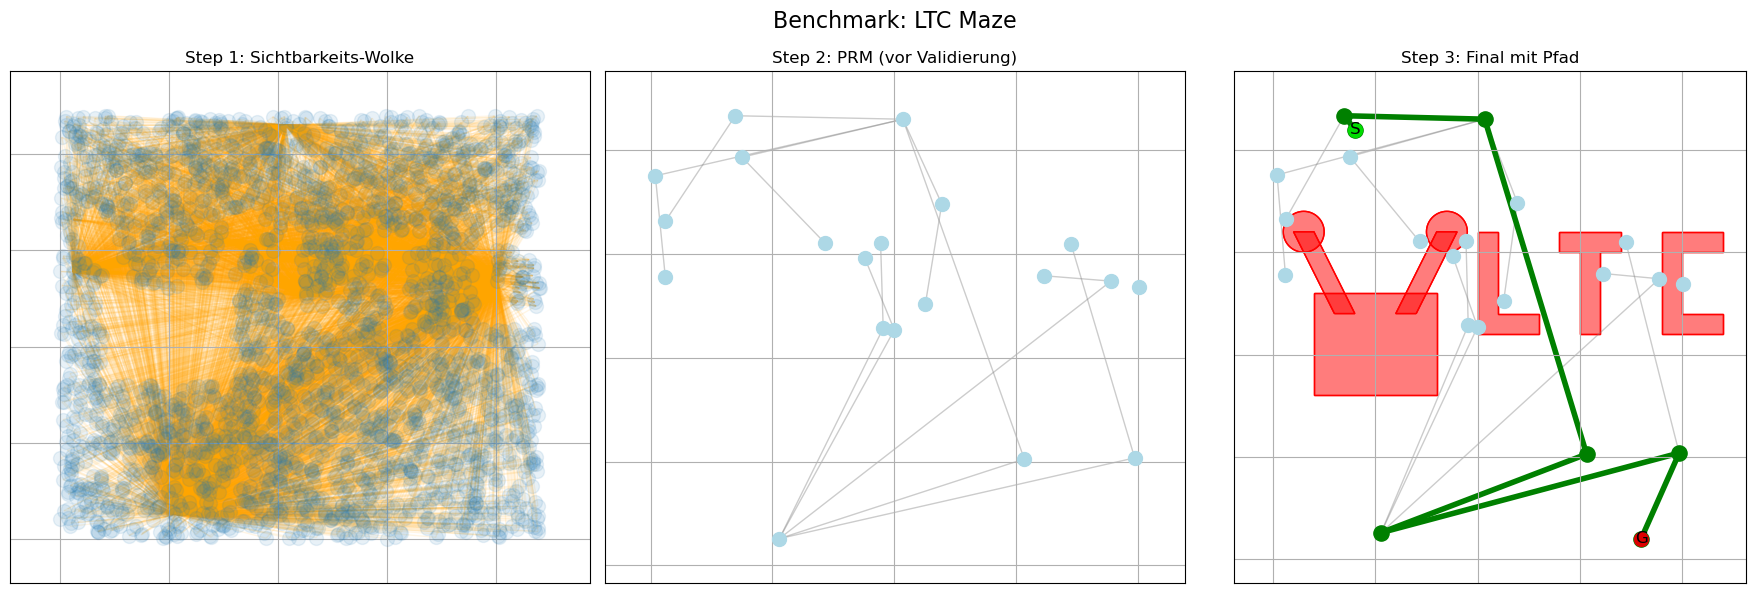


🔍 HierarchicalPRM → Maze Corridor

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 13 nodes, 12 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 13 nodes, 12 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 15 nodes, 14 edges
✅ Pfad gefunden!


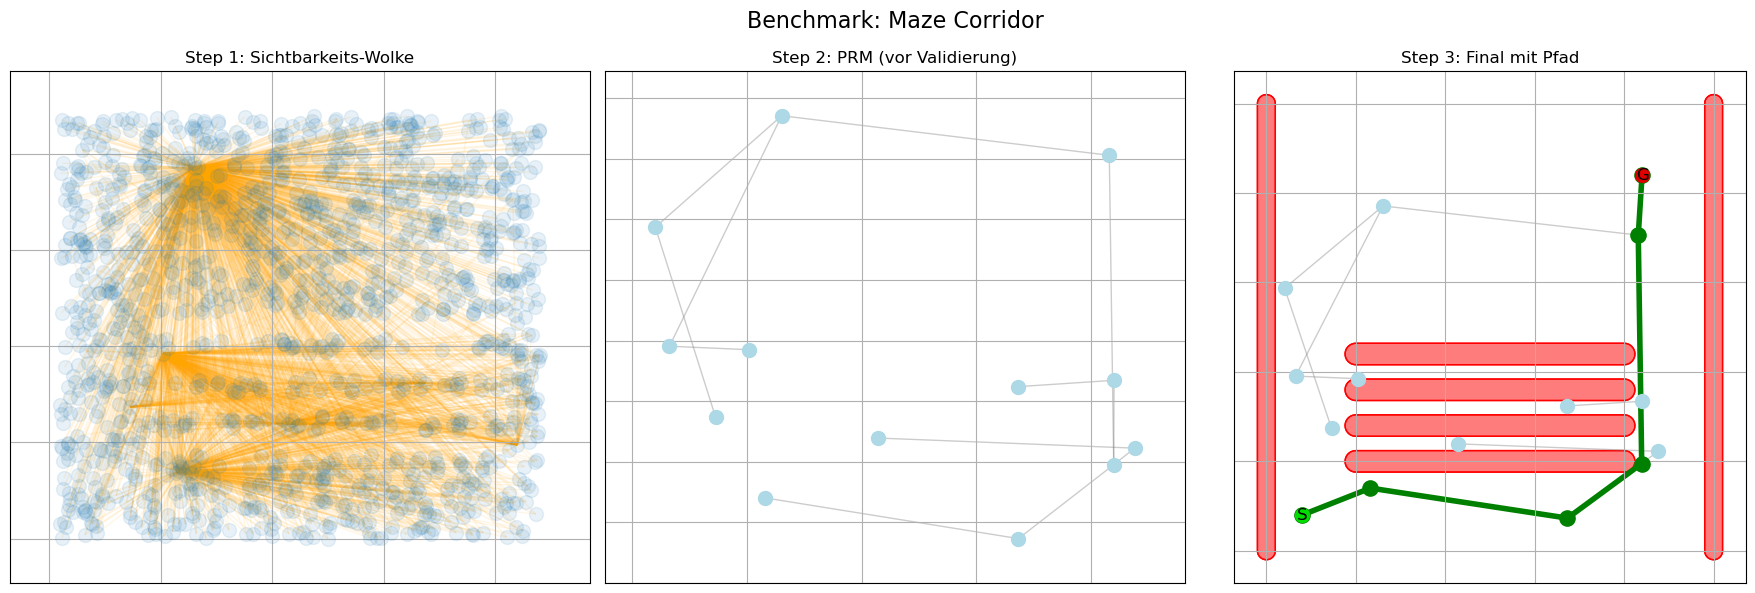


🔍 HierarchicalPRM → Diagonal Wall

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 5 nodes, 4 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 5 nodes, 4 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 7 nodes, 6 edges
✅ Pfad gefunden!


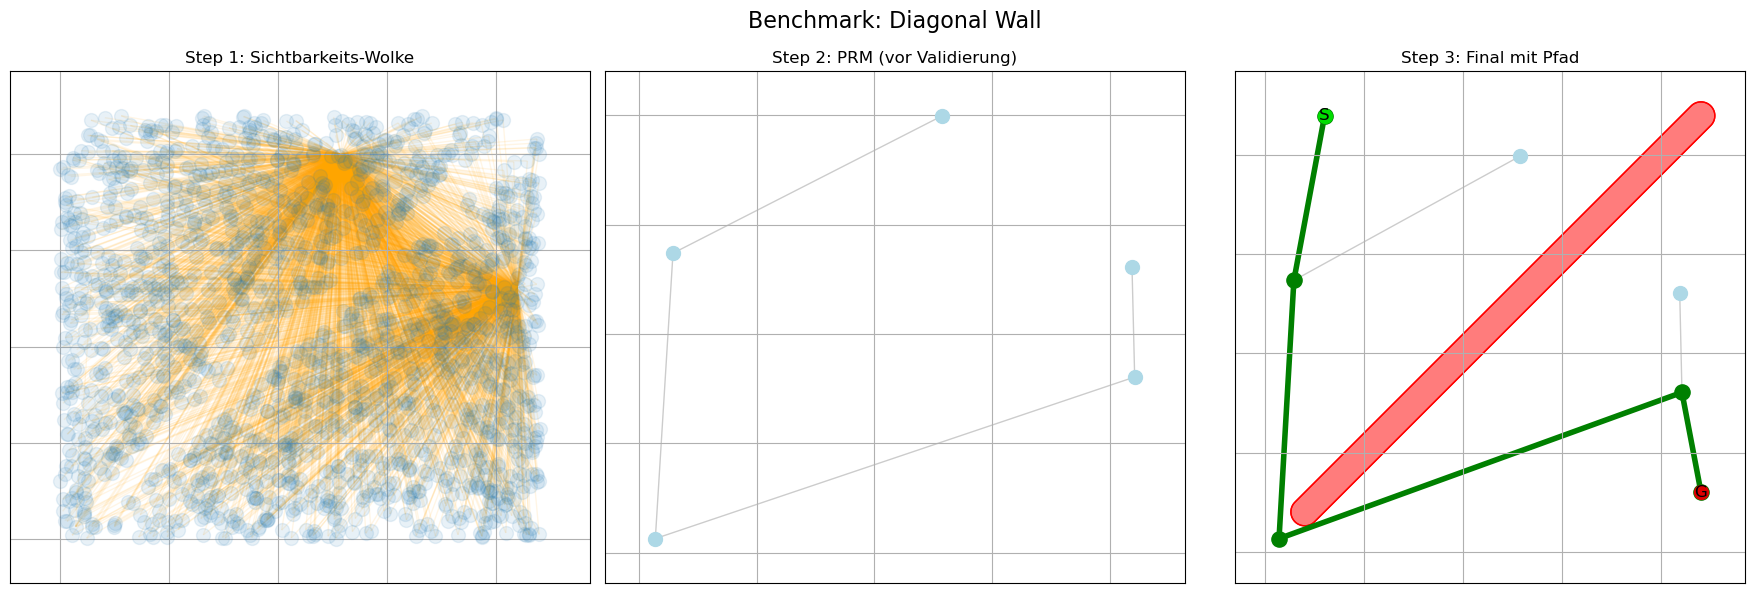


🔍 HierarchicalPRM → Corridor Split

📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 2 nodes, 0 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 2 nodes, 0 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 2 nodes, 0 edges
❌ Kein Pfad gefunden.


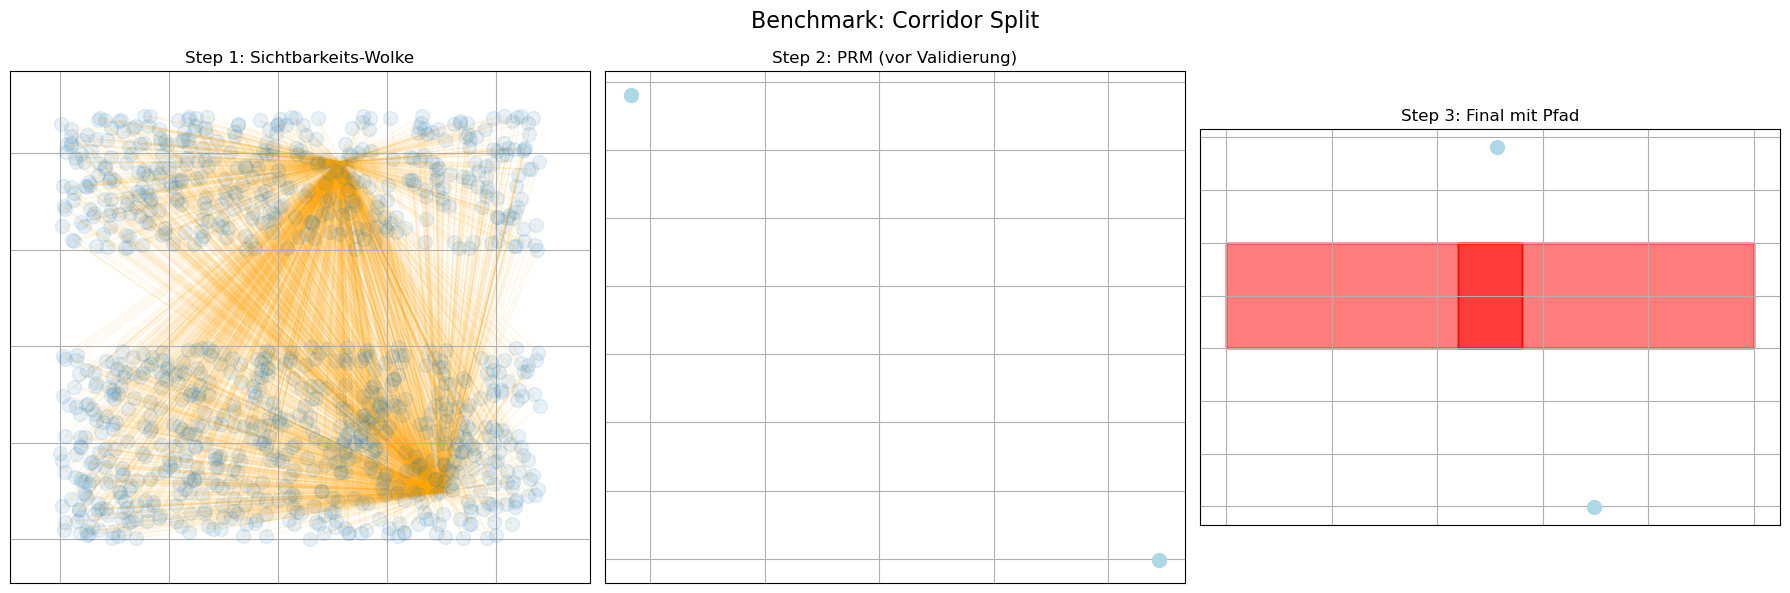

In [5]:
# 🔁 Für alle Benchmarks: HierarchicalPRM ausführen und visualisieren (3-Stufen-Darstellung)

# Setup der Planner-Factories
mainPlannerFactory = lambda cc: VisPRM(cc)
subPlannerFactory = lambda cc: LazyPRM(cc)

# Konfiguration (z. B. für VisPRM)
visConfig = dict()
visConfig["ntry"] = 1000

# Benchmark-Schleife
for benchmark in benchmarks:
    print(f"\n🔍 HierarchicalPRM → {benchmark.name}")
    
    # 1. Planer instanziieren
    planner = HierarchicalPRM(benchmark.collisionChecker, mainPlannerFactory, subPlannerFactory)

    # 2. Pfad berechnen
    path = planner.planPath(benchmark.startList, benchmark.goalList, visConfig)

    # 3. Visualisierung (3 Schritte)
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    hierarchicalPRMVisualizeLazySteps(planner, axs)
    fig.suptitle(f"Benchmark: {benchmark.name}", fontsize=16)
    plt.tight_layout()
    plt.show()



📌 [Step 3] Creating MainPlanner and learning roadmap
🧠 MainPlanner learned: 7 nodes, 6 edges
🔍 [Step 4] Validating with SubPlanner...
⚠️ 0 edges removed by SubPlanner.
📊 Validated Graph: 7 nodes, 6 edges
🔗 [Step 5] Connecting start/goal
🧷 Start/Goal verbunden. Finaler Graph: 9 nodes, 8 edges
✅ Pfad gefunden!


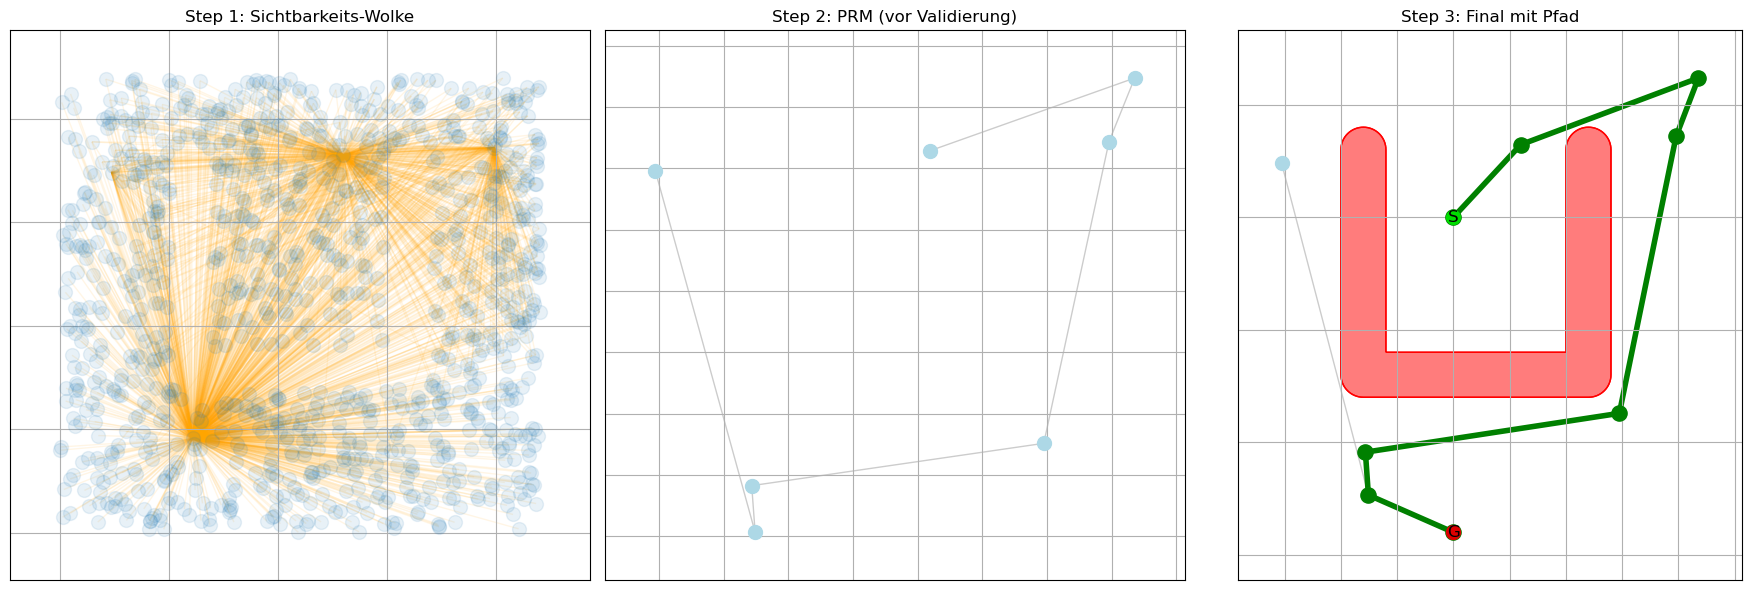

In [8]:
# Für LazyPRM als SubPlanner
subPlannerFactory = lambda cc: LazyPRM(cc)
planner = HierarchicalPRM(benchmark.collisionChecker, mainPlannerFactory, subPlannerFactory)
path = planner.planPath(benchmark.startList, benchmark.goalList, visConfig)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
hierarchicalPRMVisualizeLazySteps(planner, axs)
plt.tight_layout()
plt.show()


In [6]:
# 🧠 Results Container
class Result:
    def __init__(self, plannerName, planner, benchmark, solution, perf):
        self.plannerName = plannerName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perf = perf


In [7]:
# 🚀 Benchmark-Durchführung
results = []
for key, (PlannerClass, config, visualizer) in plannerFactory.items():
    print(f"\n🔍 {key}")
    for benchmark in benchmarks:
        print(f"   → {benchmark.name}")
        planner = PlannerClass(benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            path = planner.planPath(benchmark.startList, benchmark.goalList, config)
            perf = IPPerfMonitor.dataFrame()
            results.append(Result(key, planner, benchmark, path, perf))
        except Exception as e:
            print("   ⚠️ Error:", e)



🔍 VisPRM
   → Trap
   → Bottleneck
   → Fat Bottleneck
   → LTC Maze
   → Maze Corridor
   → Diagonal Wall
   → Corridor Split
   ⚠️ Error: No valid start

🔍 LazyPRM
   → Trap
   → Bottleneck
   → Fat Bottleneck
   → LTC Maze
   → Maze Corridor
   → Diagonal Wall
   → Corridor Split
   ⚠️ Error: No valid start

🔍 HierarchicalPRM
   → Trap


TypeError: HierarchicalPRM.__init__() missing 1 required positional argument: 'mainPlannerFactory'

In [ ]:
# 🖼️ Visualisierung aller Lösungen
for result in results:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_title(f"{result.plannerName} - {result.benchmark.name}")
    ax.set_xlim(result.benchmark.collisionChecker.getEnvironmentLimits()[0])
    ax.set_ylim(result.benchmark.collisionChecker.getEnvironmentLimits()[1])
    result.benchmark.collisionChecker.drawObstacles(ax)

    start = Point(result.benchmark.startList[0])
    goal = Point(result.benchmark.goalList[0])
    plotting.plot_points(start.buffer(0.3), color="green", ax=ax)
    plotting.plot_points(goal.buffer(0.3), color="red", ax=ax)

    # Draw roadmap and path
    plannerFactory[result.plannerName][2](result.planner, result.solution, ax=ax)
    plt.grid(True)
    plt.show()


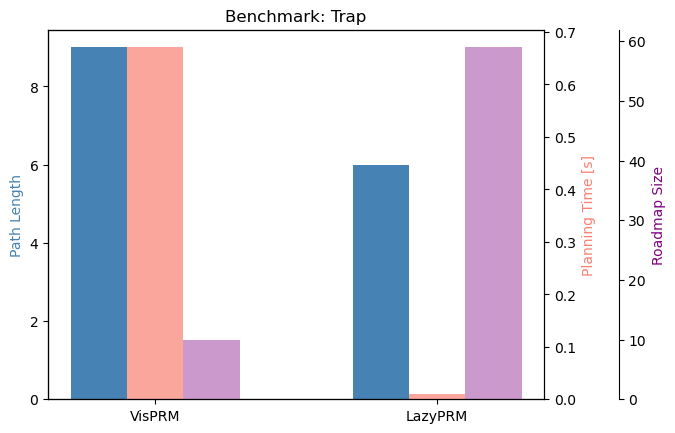

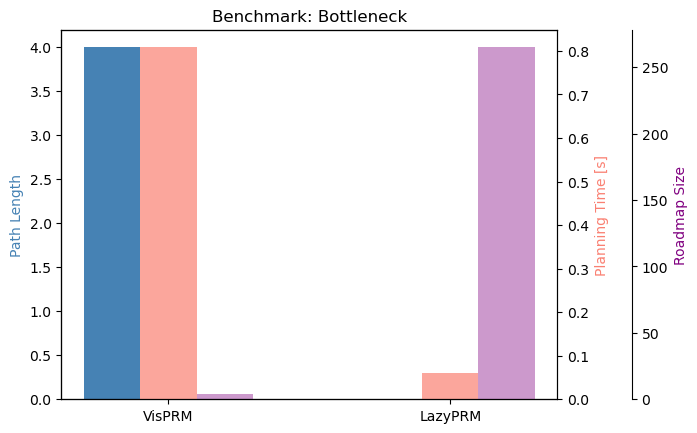

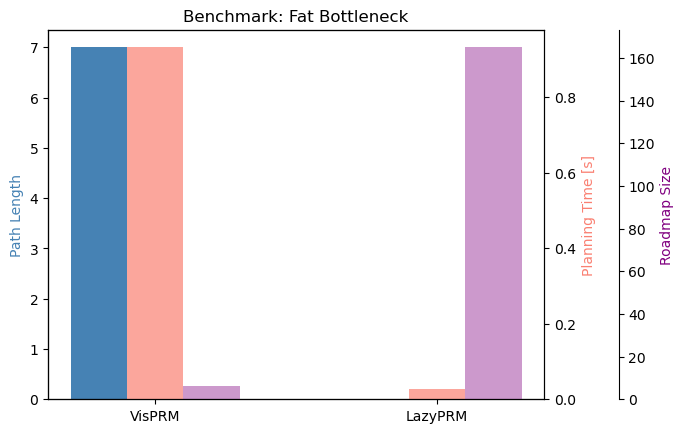

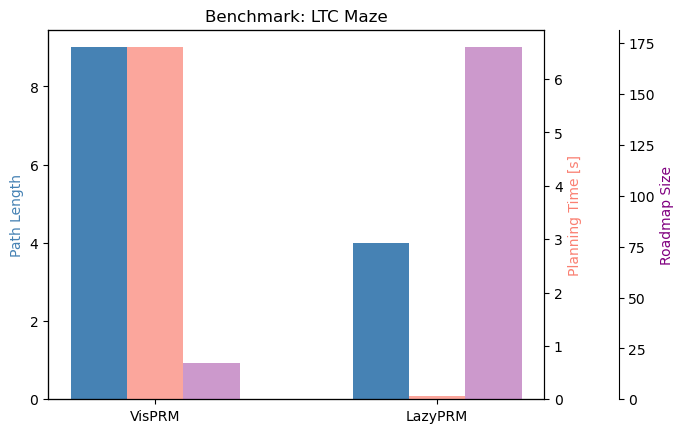

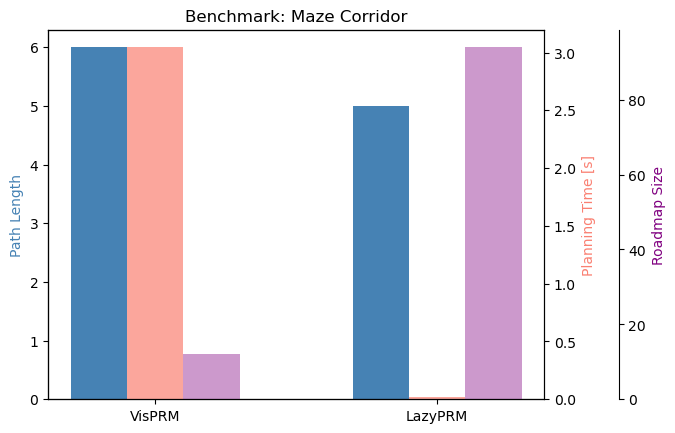

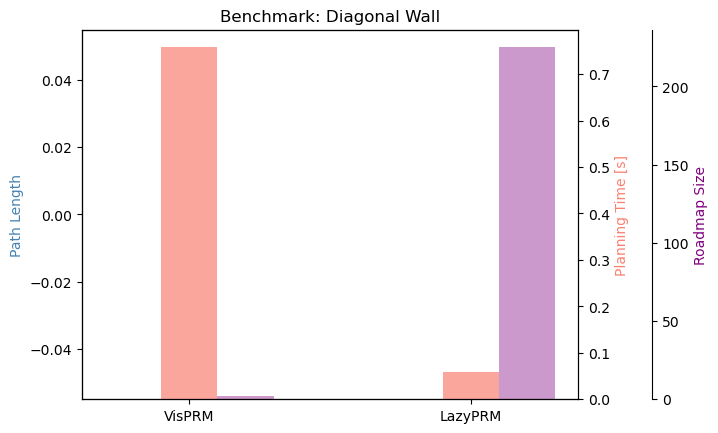

In [9]:
# 📊 Metriken vergleichen (Knotenanzahl, Zeit, Größe)
for bench in benchmarks:
    title = bench.name
    pathLength = dict()
    planningTime = dict()
    roadmapSize = dict()

    for r in results:
        if r.benchmark.name != bench.name:
            continue
        pathLength[r.plannerName] = len(r.solution)
        planningTime[r.plannerName] = r.perf.groupby("name").sum(numeric_only=True)["time"]["planPath"]
        roadmapSize[r.plannerName] = r.planner.graph.size()

    if not pathLength:
        continue

    fig, ax = plt.subplots()
    width = 0.2
    keys = list(pathLength.keys())

    ax.bar(np.arange(len(keys)), pathLength.values(), width, label="Nodes in Path", color="steelblue")
    ax.set_ylabel("Path Length", color="steelblue")
    ax.set_xticks(np.arange(len(keys)) + width)
    ax.set_xticklabels(keys)

    ax2 = ax.twinx()
    bars2 = ax2.bar(np.arange(len(keys)) + width, planningTime.values(), width, color="salmon", alpha=0.7,
                    label="Planning Time")
    ax2.set_ylabel("Planning Time [s]", color="salmon")

    ax3 = ax.twinx()
    bars3 = ax3.bar(np.arange(len(keys)) + 2 * width, roadmapSize.values(), width, color="purple", alpha=0.4,
                    label="Graph Size")
    ax3.spines['right'].set_position(('axes', 1.15))
    ax3.set_ylabel("Roadmap Size", color="purple")

    ax.set_title(f"Benchmark: {title}")
    plt.show()


In [ ]:
# 🖼️ Visualisierung aller Lösungen
for result in results:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_title(f"{result.plannerName} - {result.benchmark.name}")
    ax.set_xlim(result.benchmark.collisionChecker.getEnvironmentLimits()[0])
    ax.set_ylim(result.benchmark.collisionChecker.getEnvironmentLimits()[1])
    result.benchmark.collisionChecker.drawObstacles(ax)

    start = Point(result.benchmark.startList[0])
    goal = Point(result.benchmark.goalList[0])
    plotting.plot_points(start.buffer(0.3), color="green", ax=ax)
    plotting.plot_points(goal.buffer(0.3), color="red", ax=ax)

    # Draw roadmap and path
    plannerFactory[result.plannerName][2](result.planner, result.solution, ax=ax)
    plt.grid(True)
    plt.show()

## 🧠 1. Hierarchischer Planer

Ein hierarchischer Planer kombiniert zwei Planungsebenen:

- **Hauptplaner:** Globales Verfahren (z. B. Visibility-Roadmap), um grobe Pfade zwischen Regionen zu planen.
- **Innerer Planer:** Lokaler Feingeist (z. B. PRM oder LazyPRM), um zwischen zwei Waypoints eine konkrete, kollisionsfreie Bewegung zu finden.

### ✨ Vorteile:
- Effizienter bei komplexen Umgebungen
- Reduzierte Suchräume
- Modular kombinierbar

### 🔧 Umgesetzte Kombinationen:
- a) Visibility-Roadmap → **BasicPRM**
- b) Visibility-Roadmap → **LazyPRM**

Die Implementierung befindet sich in `hierarchical_planner.py`.

In [ ]:
from IPHierarchicalPRM import HierarchicalPRM
from IPVISHierarchicalPRM import hierarchicalPRMVisualize

# 🔧 Planner Setup (KIT Style)
plannerFactory = dict()

basicConfig = dict()
basicConfig["radius"] = 4
basicConfig["numNodes"] = 200
plannerFactory["BasicPRM"] = [BasicPRM, basicConfig, basicPRMVisualize]

visConfig = dict()
visConfig["ntry"] = 50
plannerFactory["VisPRM"] = [VisPRM, visConfig, visibilityPRMVisualize]

# ➕ NEU: Hierarchical Planner eintragen
hierConfig = dict()
hierConfig["mainPlanner"] = VisPRM
hierConfig["mainConfig"] = visConfig
hierConfig["subPlanner"] = BasicPRM
hierConfig["subConfig"] = basicConfig
plannerFactory["Hierarchical"] = [HierarchicalPRM, hierConfig, hierarchicalPRMVisualize]

# 🧪 Benchmarks laden
benchmarks = getAllBenchmarks()

# 🧠 Results Container
class Result:
    def __init__(self, plannerName, planner, benchmark, solution, perf):
        self.plannerName = plannerName
        self.planner = planner
        self.benchmark = benchmark
        self.solution = solution
        self.perf = perf

# 🚀 Benchmark-Durchführung für alle Planner aus Factory
results = []
for key, (PlannerClass, config, visualizer) in plannerFactory.items():
    print(f"\n🔍 {key}")
    for benchmark in benchmarks:
        print(f"   → {benchmark.name}")
        planner = PlannerClass(benchmark.collisionChecker)
        IPPerfMonitor.clearData()
        try:
            path = planner.planPath(benchmark.startList, benchmark.goalList, config)
            perf = IPPerfMonitor.dataFrame()
            results.append(Result(key, planner, benchmark, path, perf))
        except Exception as e:
            print("   ⚠️ Error:", e)

In [ ]:
# 🖼️ Visualisierung aller Lösungen – robust auch bei Fehlern oder leeren Pfaden
for result in results:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_title(f"{result.plannerName} - {result.benchmark.name}")
    ax.set_xlim(result.benchmark.collisionChecker.getEnvironmentLimits()[0])
    ax.set_ylim(result.benchmark.collisionChecker.getEnvironmentLimits()[1])
    ax.set_aspect("equal")
    ax.grid(True)

    # Hindernisse
    result.benchmark.collisionChecker.drawObstacles(ax)

    # Start / Ziel
    start = Point(result.benchmark.startList[0])
    goal = Point(result.benchmark.goalList[0])
    plotting.plot_points(start.buffer(0.3), color="green", ax=ax)
    plotting.plot_points(goal.buffer(0.3), color="red", ax=ax)

    # 🔍 Visualisierung mit passendem Visualizer
    if result.plannerName in plannerFactory:
        try:
            plannerFactory[result.plannerName][2](result.planner, result.solution, ax=ax)
        except Exception as e:
            print(f"⚠️ Fehler bei Visualizer für {result.plannerName} - {result.benchmark.name}: {e}")
    else:
        try:
            # Sonderfall: Planner nicht in Factory (z. B. extern eingebundener Planer)
            # Versuche generischen Aufruf
            if hasattr(result.planner, "graph"):
                nx.draw(result.planner.graph, ax=ax)
            else:
                print(f"⚠️ Kein Visualizer für {result.plannerName}")
        except Exception as e:
            print(f"⚠️ Fehler beim Fallback-Plot für {result.plannerName}: {e}")

    # Hinweis bei fehlender Lösung
    if not result.solution:
        print(f"⚠️ {result.plannerName} - {result.benchmark.name}: Keine Lösung gefunden")

    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict
from shapely.geometry import Point
import networkx as nx
import math

# Ergebnisse nach Benchmark gruppieren
benchmark_groups = defaultdict(list)
for result in results:
    benchmark_groups[result.benchmark.name].append(result)

# Visualisierung pro Benchmark mit Subplots für alle zugehörigen Algorithmen
for benchmark_name, group in benchmark_groups.items():
    num_algorithms = len(group)

    # Layout: max 3 Spalten
    cols = min(3, num_algorithms)
    rows = math.ceil(num_algorithms / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 7 * rows))
    axes = axes.flatten() if num_algorithms > 1 else [axes]

    for i, result in enumerate(group):
        ax = axes[i]
        ax.set_title(f"{result.plannerName} ({benchmark_name})")
        ax.set_aspect("equal")
        ax.grid(True)

        # Hindernisse zuerst zeichnen
        try:
            result.benchmark.collisionChecker.drawObstacles(ax)
        except Exception as e:
            print(f"⚠️ Fehler beim Zeichnen der Hindernisse: {e}")

        # Start / Ziel
        try:
            start = Point(result.benchmark.startList[0])
            goal = Point(result.benchmark.goalList[0])
            plotting.plot_points(start.buffer(0.3), color="green", ax=ax)
            plotting.plot_points(goal.buffer(0.3), color="red", ax=ax)
        except Exception as e:
            print(f"⚠️ Fehler beim Zeichnen von Start/Ziel: {e}")

        # Achsenlimits setzen (nach Hindernissen)
        try:
            xlim, ylim = result.benchmark.collisionChecker.getEnvironmentLimits()
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
        except Exception as e:
            print(f"⚠️ Fehler bei Axenlimits: {e}")

        # 🔍 Visualisierung der Lösung
        try:
            if result.plannerName in plannerFactory:
                plannerFactory[result.plannerName][2](result.planner, result.solution, ax=ax)
            elif hasattr(result.planner, "graph"):
                nx.draw(result.planner.graph, ax=ax)
            else:
                print(f"⚠️ Kein Visualizer für {result.plannerName}")
        except Exception as e:
            print(f"⚠️ Fehler bei Visualizer für {result.plannerName} - {benchmark_name}: {e}")

        # Hinweis bei fehlender Lösung
        if not result.solution:
            print(f"⚠️ {result.plannerName} - {benchmark_name}: Keine Lösung gefunden")

    # Entferne ungenutzte Subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Benchmark: {benchmark_name}", fontsize=16)
    plt.tight_layout()
    plt.show()
